# Algoritmos de optimización - Seminario
Nombre y Apellidos:    <br>
- Guido Quispe Quispe <br>
- Johan Sebastian Sanchez Ballen <br>

GRUPO: 39<br>
<br>
Url: https://github.com/Guidouib/Algoritmos_de_Optimizacion/tree/main/PROYECTO%20(Trabajo%20Pr%C3%A1ctico)%201a%20Conv <br>
Problema:
>3. Combinar cifras y operaciones

### Descripción del problema (enunciado)

Disponemos de las **9 cifras del 1 al 9** (se excluye el cero) y de los **4 signos** de las
operaciones fundamentales: suma (`+`), resta (`-`), multiplicación (`*`) y división (`/`).

Debemos combinarlos **alternativamente y sin repetir ninguno** de ellos para obtener una
cantidad dada. La expresión tiene por tanto la forma:

```
D1 op1 D2 op2 D3 op3 D4 op4 D5
```

es decir, **5 cifras distintas** (elegidas de las 9) y **los 4 operadores, cada uno usado una sola vez**.
Un ejemplo para obtener el 4 sería:

```
4 + 2 - 6 / 3 * 1 = 4
```

Se pide analizar el problema para encontrar todos los valores enteros posibles, respondiendo:
- ¿Qué valor máximo y mínimo se pueden obtener?
- ¿Es posible encontrar todos los valores enteros posibles entre dicho mínimo y máximo?

> Nota: se puede usar la función `eval` de Python para evaluar la expresión.

*(\*) La respuesta es obligatoria.*

## (*) ¿Cuántas posibilidades hay sin tener en cuenta las restricciones?

Sin restricciones (permitiendo **repetir** cifras y operadores) cada una de las 5 posiciones de
cifra admite las 9 cifras y cada una de las 4 posiciones de operador admite los 4 signos:

$$9^5 \times 4^4$$

## ¿Cuántas posibilidades hay teniendo en cuenta todas las restricciones?

Con las restricciones (cifras **distintas** y operadores **sin repetir**):

- Elegir 5 cifras distintas y ordenadas de las 9 -> variaciones $V(9,5)=P(9,5)=\dfrac{9!}{4!}$
- Ordenar los 4 operadores sin repetir -> $4!$

$$P(9,5) \times 4!$$

**Respuesta**

In [1]:
from math import perm, factorial

# --- Conteo del espacio de búsqueda ---
# SIN restricciones: se permite repetir cifras y operadores.
#   5 posiciones de cifra, cada una con 9 opciones  -> 9**5
#   4 posiciones de operador, cada una con 4 opciones -> 4**4
sin_restricciones = 9**5 * 4**4

# CON restricciones: cifras distintas (variaciones V(9,5)) y operadores sin repetir (4!)
con_restricciones = perm(9, 5) * factorial(4)   # perm(9,5) = 9!/(9-5)!

print("Sin restricciones : 9^5 * 4^4 =", sin_restricciones)
print("Con restricciones : P(9,5) * 4! =", con_restricciones)

Sin restricciones : 9^5 * 4^4 = 15116544
Con restricciones : P(9,5) * 4! = 362880


## Modelo para el espacio de soluciones
### (*) ¿Cuál es la estructura de datos que mejor se adapta al problema? Arguméntalo.

Una **solución** queda totalmente determinada por dos secuencias ordenadas:

1. una **tupla de 5 cifras** distintas (una variación de las 9 cifras), y
2. una **tupla de 4 operadores** distintos (una permutación de `('+','-','*','/')`).

La estructura elegida es, por tanto, un **par de tuplas** `(cifras, operadores)`, que se traduce
fácilmente a la cadena `str` de la expresión intercalando ambas. Motivos:

- Las **tuplas son inmutables y hashables**, lo que permite usarlas como claves y encaja
  directamente con `itertools.permutations`, que genera exactamente las variaciones sin repetición
  que exige el problema (evita generar y descartar candidatos inválidos).
- Intercalar cifras y operadores en un `str` permite evaluar con `eval` en O(1) (longitud fija).
- Para la versión mejorada usamos además un **diccionario** `{valor_entero: expresión}`: el
  diccionario (tabla hash) da acceso e inserción en O(1) medio, ideal para **memorizar** qué valores
  son alcanzables y con qué expresión, y para responder cualquier consulta objetivo al instante.

Inicialmente podría pensarse en listas, pero al necesitar hashabilidad (claves de diccionario y
conjuntos de valores alcanzables) las **tuplas + diccionario/conjunto** son la elección natural.

**Respuesta**

In [2]:
from itertools import permutations

# --- Constantes del problema ---
CIFRAS = range(1, 10)                 # cifras disponibles: 1..9 (el 0 se excluye)
OPERADORES = ('+', '-', '*', '/')     # los 4 operadores, cada uno se usará una sola vez

def construir_expresion(cifras, operadores):
    """Intercala 5 cifras y 4 operadores en la cadena de la expresión.

    cifras     : secuencia de 5 enteros distintos
    operadores : secuencia de 4 operadores distintos
    devuelve   : str con la forma  D1 op1 D2 op2 D3 op3 D4 op4 D5
    """
    partes = []
    for i in range(5):
        partes.append(str(cifras[i]))     # se añade la cifra i
        if i < 4:                          # entre cifras (no tras la última) va un operador
            partes.append(operadores[i])
    return "".join(partes)

# Comprobación con el ejemplo del enunciado: 4+2-6/3*1 debe dar 4
ej = construir_expresion((4, 2, 6, 3, 1), ('+', '-', '/', '*'))
print(ej, "=", eval(ej))

4+2-6/3*1 = 4.0


## Según el modelo para el espacio de soluciones
### (*) ¿Cuál es la función objetivo?

Dado un valor objetivo entero $N$, para cada solución $s$ (una expresión) evaluamos $eval(s)$ y
definimos la función objetivo como la **distancia al objetivo**:

$$f(s) = \lvert\, eval(s) - N \,\rvert$$

Una solución es válida (resuelve el problema) cuando $f(s) = 0$, es decir, la expresión evalúa
exactamente a $N$. De forma auxiliar, para caracterizar el rango del problema también se estudian
$\max eval(s)$ y $\min eval(s)$ sobre todo el espacio.

### (*) ¿Es un problema de maximización o minimización?

En su forma de búsqueda de un objetivo es un problema de **minimización**: se minimiza
$f(s)=\lvert eval(s)-N\rvert$ buscando el valor 0 (equivale a un problema de satisfacción de
restricciones / búsqueda). Cuando lo que se pide es el valor máximo o mínimo alcanzable, se resuelve
el problema de **maximización** y de **minimización** de $eval(s)$ respectivamente.

**Respuesta**

In [3]:
def f_objetivo(expresion, objetivo):
    """Función objetivo: distancia al valor buscado. 0 => solución exacta."""
    return abs(eval(expresion) - objetivo)

print("f para 4+2-6/3*1 con objetivo 4 =", f_objetivo("4+2-6/3*1", 4))

f para 4+2-6/3*1 con objetivo 4 = 0.0


## Diseña un algoritmo para resolver el problema por fuerza bruta

Se **enumeran todas** las combinaciones válidas: todas las variaciones de 5 cifras de las 9 y todas
las permutaciones de los 4 operadores. Para cada una se construye la expresión, se evalúa y se
comprueba si coincide con el objetivo. Guardamos además todos los valores alcanzados para poder
responder a las preguntas de máximo, mínimo y valores intermedios.

**Respuesta**

In [4]:
def fuerza_bruta(objetivo=None):
    """Enumera exhaustivamente todo el espacio de soluciones.

    objetivo : valor entero a buscar (opcional)
    devuelve : (solucion_para_objetivo, dict {valor_entero: expresion})
    """
    alcanzables = {}          # valor entero -> primera expresión que lo produce
    solucion = None           # expresión que iguala 'objetivo' (si se pide)

    # permutations(CIFRAS, 5) -> variaciones de 5 cifras sin repetir
    for cifras in permutations(CIFRAS, 5):
        # permutations(OPERADORES, 4) -> ordena los 4 operadores sin repetir
        for ops in permutations(OPERADORES, 4):
            expr = construir_expresion(cifras, ops)
            valor = eval(expr)                        # evalúa respetando precedencia * / + -
            if abs(valor - round(valor)) < 1e-9:      # nos quedamos solo con resultados enteros
                ent = round(valor)
                alcanzables.setdefault(ent, expr)     # guarda la 1ª expresión de cada valor
                # si buscamos un objetivo concreto, registramos la primera coincidencia
                if objetivo is not None and ent == objetivo and solucion is None:
                    solucion = expr
    return solucion, alcanzables

sol, alcanzables = fuerza_bruta(objetivo=4)
print("Expresión que da 4:", sol, "=", eval(sol))
print("Nº de valores enteros distintos alcanzables:", len(alcanzables))

Expresión que da 4: 1-2*3/6+4 = 4.0
Nº de valores enteros distintos alcanzables: 147


## Calcula la complejidad del algoritmo por fuerza bruta

El bucle externo recorre $P(9,5)$ variaciones de cifras y el interno $4!$ permutaciones de
operadores. Cada iteración construye y evalúa una expresión de longitud fija (coste $O(1)$):

$$P(9,5)\cdot 4! = 15120 \cdot 24 = 362\,880 \text{ evaluaciones}$$

Generalizando a $n$ cifras tomadas de $k$ en $k$ y $m$ operadores:

$$O\!\left(P(n,k)\cdot m!\right) = O\!\left(\frac{n!}{(n-k)!}\, m!\right)$$

Es un crecimiento **factorial**: para el tamaño del enunciado es perfectamente asumible (~3,6·10^5),
pero se dispara si aumentan las cifras u operadores.

**Respuesta**

In [5]:
import time
t0 = time.perf_counter()
_, alcanzables = fuerza_bruta()
t1 = time.perf_counter()
print("Combinaciones evaluadas:", perm(9,5)*factorial(4))
print(f"Tiempo fuerza bruta: {t1-t0:.3f} s")

Combinaciones evaluadas: 362880
Tiempo fuerza bruta: 2.064 s


## (*) Diseña un algoritmo que mejore la complejidad de la fuerza bruta. Argumenta por qué mejora.

La fuerza bruta vuelve a recorrer las 362.880 combinaciones **cada vez** que se pregunta por un
objetivo. Dos mejoras:

**1) Precálculo + tabla hash (memoización).** El espacio es fijo y pequeño, así que lo recorremos
**una sola vez** y guardamos en un diccionario `{valor: expresión}` todos los enteros alcanzables.
A partir de ahí, **responder a cualquier objetivo es O(1)** (una búsqueda en el diccionario). Si hay
que resolver $q$ objetivos, pasamos de $O(q\cdot P(9,5)\,4!)$ a $O(P(9,5)\,4! + q)$.

**2) Backtracking con poda.** Si sólo interesa *un* objetivo, se construye la expresión posición a
posición y se **poda** en cuanto una rama no puede llevar a la solución, evitando expandir el
subárbol completo. En el peor caso sigue siendo factorial, pero en la práctica explora muchísimos
menos nodos que la enumeración total.

La mejora clave es **no repetir trabajo**: se cambia cómputo por memoria (diccionario) y/o se
descartan ramas inútiles antes de completarlas.

**Respuesta**

In [6]:
class Resolutor:
    """Enfoque mejorado 1: precálculo + tabla hash (memoización).

    Recorre el espacio UNA sola vez en el constructor y almacena en un diccionario
    {valor_entero: expresión}. Después, cada consulta se responde en O(1).
    """
    def __init__(self):
        self.tabla = {}       # valor entero -> primera expresión que lo genera
        # recorrido único de todo el espacio (mismo coste que la fuerza bruta)
        for cifras in permutations(CIFRAS, 5):
            for ops in permutations(OPERADORES, 4):
                expr = construir_expresion(cifras, ops)
                v = eval(expr)
                if abs(v - round(v)) < 1e-9:              # solo resultados enteros
                    self.tabla.setdefault(round(v), expr)  # no sobrescribe si ya existe

    def resolver(self, objetivo):
        """Consulta O(1): devuelve la expresión para 'objetivo' o None si no existe."""
        return self.tabla.get(objetivo)


def backtracking(objetivo):
    """Enfoque mejorado 2: búsqueda con poda para un único objetivo.

    Construye la expresión posición a posición alternando cifra/operador (sin repetir)
    y corta la rama en cuanto encuentra una solución, sin generar el resto del espacio.
    """
    sol = []
    def expandir(cifras, ops):
        # caso base: 5 cifras + 4 operadores => expresión completa
        if len(cifras) == 5 and len(ops) == 4:
            expr = construir_expresion(cifras, ops)
            if abs(eval(expr) - objetivo) < 1e-9:   # ¿coincide con el objetivo?
                sol.append(expr)
                return True                          # poda: deja de buscar
            return False
        # la expresión empieza y alterna: cifra, operador, cifra, ... => decide qué toca
        if len(cifras) == len(ops):        # mismas cantidades => toca poner una cifra
            for c in CIFRAS:
                if c not in cifras and expandir(cifras + [c], ops):
                    return True
        else:                               # hay una cifra de más => toca operador
            for o in OPERADORES:
                if o not in ops and expandir(cifras, ops + [o]):
                    return True
        return False
    expandir([], [])
    return sol[0] if sol else None

resolutor = Resolutor()
print("resolver(4)    ->", resolutor.resolver(4))
print("resolver(77)   ->", resolutor.resolver(77))
print("resolver(1000) ->", resolutor.resolver(1000))
print("backtracking(4) ->", backtracking(4))

resolver(4)    -> 1-2*3/6+4
resolver(77)   -> 7/1-2+8*9
resolver(1000) -> None
backtracking(4) -> 1+3*8/2-9


## (*) Calcula la complejidad del algoritmo

**Precálculo + tabla hash:** construir la tabla cuesta $O(P(9,5)\cdot 4!)$ **una única vez**; cada
consulta posterior es $O(1)$ (acceso a diccionario). Para $q$ consultas:

$$O\big(P(9,5)\cdot 4! + q\big)\ \text{frente a}\ O\big(q\cdot P(9,5)\cdot 4!\big)$$

de la fuerza bruta ingenua. La memoria adicional es $O(V)$, con $V=147$ valores enteros distintos.

**Backtracking con poda:** peor caso $O(P(9,5)\cdot 4!)$ (factorial), pero el número de nodos
realmente expandidos es muy inferior porque las ramas que no llevan al objetivo se cortan antes de
completarse; para una sola consulta suele encontrar la solución tras explorar una fracción del
espacio.

**Respuesta**

In [7]:
import time
t0 = time.perf_counter(); r = Resolutor(); t1 = time.perf_counter()
objetivos = list(range(-69, 78))
t2 = time.perf_counter()
_ = [r.resolver(o) for o in objetivos]      # 147 consultas O(1)
t3 = time.perf_counter()
print(f"Construir tabla (1 vez): {t1-t0:.3f} s")
print(f"147 consultas O(1): {t3-t2:.6f} s")

Construir tabla (1 vez): 1.788 s
147 consultas O(1): 0.000054 s


## Según el problema (y tenga sentido), diseña un juego de datos de entrada aleatorio

El "dato de entrada" natural es el **valor objetivo**. Generamos objetivos enteros aleatorios,
tanto dentro del rango alcanzable como fuera de él, para comprobar el comportamiento del algoritmo
en ambos casos.

**Respuesta**

In [8]:
import random
random.seed(42)

# objetivos: mezcla de valores dentro (-69..77) y fuera del rango
objetivos_aleatorios = [random.randint(-90, 100) for _ in range(10)]
print("Objetivos aleatorios:", objetivos_aleatorios)

Objetivos aleatorios: [73, -62, -84, 99, -20, -28, -33, -55, 98, -64]


## Aplica el algoritmo al juego de datos generado

Resolvemos cada objetivo aleatorio con el `Resolutor` (consulta O(1)) y, de paso, calculamos el
**máximo y el mínimo entero** alcanzables y verificamos si **todos** los enteros intermedios lo son.

**Respuesta**

In [9]:
r = Resolutor()      # construye la tabla de valores alcanzables una sola vez

# 1) Resolvemos cada objetivo aleatorio (consulta O(1) en la tabla)
print("=== Resolución de objetivos aleatorios ===")
for obj in objetivos_aleatorios:
    expr = r.resolver(obj)
    if expr:
        print(f"  {obj:>4} = {expr}  (comprobación: {eval(expr):.4g})")
    else:
        print(f"  {obj:>4} -> NO alcanzable")

# 2) Análisis del rango: mínimo, máximo y posibles huecos intermedios
enteros = sorted(r.tabla.keys())
minimo, maximo = enteros[0], enteros[-1]
# 'faltan' recoge los enteros del intervalo [min, max] que NO son alcanzables
faltan = [x for x in range(minimo, maximo + 1) if x not in r.tabla]
print("\n=== Análisis del rango ===")
print("Valor entero MÍNIMO alcanzable:", minimo, "->", r.tabla[minimo])
print("Valor entero MÁXIMO alcanzable:", maximo, "->", r.tabla[maximo])
print("Nº de enteros distintos alcanzables:", len(enteros))
print("Enteros que FALTAN en [min, max]:", faltan)
print("¿Se alcanzan TODOS los enteros del intervalo?:", len(faltan) == 0)

=== Resolución de objetivos aleatorios ===
    73 = 3/1-2+8*9  (comprobación: 73)
   -62 = 3/1+7-8*9  (comprobación: -62)
   -84 -> NO alcanzable
    99 -> NO alcanzable
   -20 = 1+3-6/2*8  (comprobación: -20)
   -28 = 1-4*8+6/2  (comprobación: -28)
   -33 = 1-4*9+6/3  (comprobación: -33)
   -55 = 2/1+6-7*9  (comprobación: -55)
    98 -> NO alcanzable
   -64 = 2/1+6-8*9  (comprobación: -64)

=== Análisis del rango ===
Valor entero MÍNIMO alcanzable: -69 -> 1+4/2-8*9
Valor entero MÁXIMO alcanzable: 77 -> 7/1-2+8*9
Nº de enteros distintos alcanzables: 147
Enteros que FALTAN en [min, max]: []
¿Se alcanzan TODOS los enteros del intervalo?: True


### Visualización: distribución de resultados

Para ilustrar el rango de valores, representamos **cuántas expresiones** producen cada resultado
entero. Se aprecia que la distribución se concentra alrededor de 0 y que el intervalo
$[-69, 77]$ se cubre por completo.

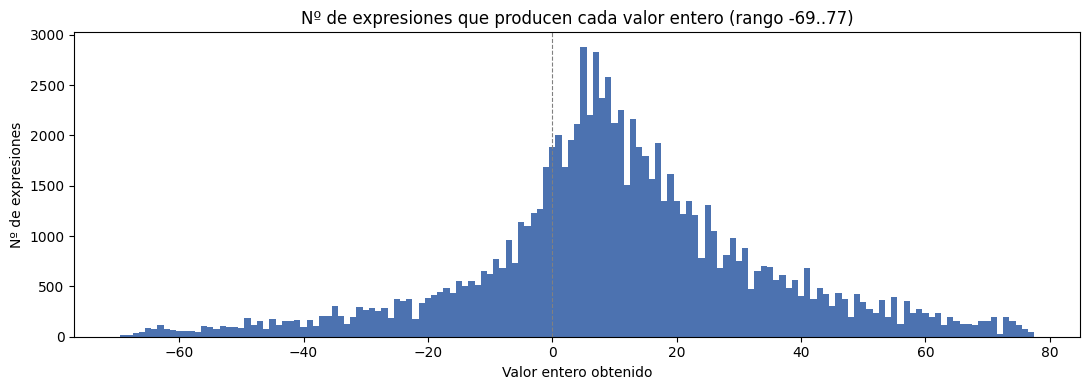

In [10]:
import matplotlib.pyplot as plt
from collections import Counter

# Contamos cuántas expresiones válidas producen cada valor entero
frecuencias = Counter()
for cifras in permutations(CIFRAS, 5):
    for ops in permutations(OPERADORES, 4):
        v = eval(construir_expresion(cifras, ops))
        if abs(v - round(v)) < 1e-9:
            frecuencias[round(v)] += 1

xs = sorted(frecuencias)
ys = [frecuencias[x] for x in xs]

plt.figure(figsize=(11, 4))
plt.bar(xs, ys, width=1.0, color="#4C72B0")
plt.axvline(0, color="grey", linewidth=0.8, linestyle="--")
plt.title("Nº de expresiones que producen cada valor entero (rango -69..77)")
plt.xlabel("Valor entero obtenido")
plt.ylabel("Nº de expresiones")
plt.tight_layout()
plt.show()

### Conclusión del análisis

- El **máximo** valor entero es **77** y el **mínimo** es **-69**.
  (Los extremos reales sin redondear son ~78,83 con `7-1/6+8*9` y ~-70,71 con `1+2/7-8*9`,
  pero no son enteros.)
- Entre -69 y 77 se alcanzan los **147** enteros del intervalo **sin ninguna laguna**: la respuesta
  a "¿es posible encontrar todos los valores enteros entre el mínimo y el máximo?" es **sí**.

## Enumera las referencias que has utilizado

- Documentación oficial de Python: `itertools.permutations`, función `eval`, `math.perm`,
  `math.factorial` — https://docs.python.org/3/library/itertools.html
- Brassard, G. y Bratley, P. (1997). *Fundamentos de algoritmia*.
- Guerequeta, R. y Vallecillo, A. (2000). *Técnicas de diseño de algoritmos* (backtracking).
- Material de la asignatura 03MIAR – Algoritmos de Optimización (VIU).

## Describe cómo es posible avanzar en el estudio del problema

- **Aumentar el tamaño:** usar las 9 cifras (o repetirlas), permitir más operadores o el 0, o
  cadenas más largas hace que el espacio crezca de forma factorial; ahí la enumeración deja de ser
  viable y conviene recurrir a **metaheurísticas** (búsqueda local, recocido simulado, algoritmos
  genéticos) minimizando $f(s)=|eval(s)-N|$.
- **Variaciones del enunciado:** permitir **paréntesis** (cambia la precedencia y amplía el rango
  de valores), permitir repetición de cifras/operadores, o fijar operadores como binarios/unarios.
- **Preguntas derivadas:** ¿cuántas expresiones distintas producen cada valor? (histograma de
  frecuencias), ¿cuál es la expresión "más corta" o "más simple" para cada objetivo?
- **Optimización del cálculo:** paralelizar la enumeración, o construir la tabla de alcanzables con
  **programación dinámica** sobre subexpresiones para no reevaluar prefijos.